In [1]:
import pandas as pd
import numpy as np

orders = pd.read_csv("../data/Orders.csv")
details = pd.read_csv("../data/Details.csv")

print("Orders shape:", orders.shape)
print("Details shape:", details.shape)

Orders shape: (500, 5)
Details shape: (1500, 7)


In [2]:
print("ORDERS DATA")
print(orders.info())

print("\nDETAILS DATA")
print(details.info())

ORDERS DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB
None

DETAILS DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
 6   PaymentMode   1500 non-null   object
dtypes: int64(3), object(4)
memory usage: 82.2

In [3]:
print("Missing values in Orders:")
print(orders.isnull().sum())

print("\nMissing values in Details:")
print(details.isnull().sum())

Missing values in Orders:
Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
dtype: int64

Missing values in Details:
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
dtype: int64


In [4]:
print("Duplicate rows in Orders:", orders.duplicated().sum())
print("Duplicate rows in Details:", details.duplicated().sum())

Duplicate rows in Orders: 0
Duplicate rows in Details: 0


In [5]:
# Check whether every Order ID in Details exists in Orders

orders_ids = set(orders["Order ID"])
details_ids = set(details["Order ID"])

missing_orders = details_ids - orders_ids

print("Order IDs in Orders:", len(orders_ids))
print("Order IDs in Details:", len(details_ids))
print("Order IDs in Details missing from Orders:", len(missing_orders))

if len(missing_orders) == 0:
    print("Relationship check: PASSED")
else:
    print("Missing Order IDs:", missing_orders)

Order IDs in Orders: 500
Order IDs in Details: 500
Order IDs in Details missing from Orders: 0
Relationship check: PASSED


In [6]:
print(orders["Order Date"].head(10))
print("\nData type:", orders["Order Date"].dtype)

0    10-03-2018
1    03-02-2018
2    24-01-2018
3    27-12-2018
4    21-08-2018
5    21-01-2018
6    16-01-2018
7    27-03-2018
8    01-10-2018
9    01-04-2018
Name: Order Date, dtype: object

Data type: object


In [7]:
orders["Order Date"] = pd.to_datetime(
    orders["Order Date"],
    format="%d-%m-%Y"
)

print(orders["Order Date"].head())
print("\nData type:", orders["Order Date"].dtype)
print("\nDate range:")
print(orders["Order Date"].min(), "to", orders["Order Date"].max())

0   2018-03-10
1   2018-02-03
2   2018-01-24
3   2018-12-27
4   2018-08-21
Name: Order Date, dtype: datetime64[ns]

Data type: datetime64[ns]

Date range:
2018-01-01 00:00:00 to 2018-12-31 00:00:00


In [8]:
print("Unique states:")
print(sorted(orders["State"].unique()))

print("\nNumber of unique states:", orders["State"].nunique())

Unique states:
['Andhra Pradesh', 'Bihar', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Karnataka', 'Kerala ', 'Madhya Pradesh', 'Maharashtra', 'Nagaland', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']

Number of unique states: 19


In [9]:
print("States with leading/trailing spaces:")

for state in orders["State"].unique():
    if state != state.strip():
        print(repr(state))

States with leading/trailing spaces:
'Kerala '


In [10]:
orders["State"] = orders["State"].str.strip()

print("States after cleaning:")
print(sorted(orders["State"].unique()))

print("\nNumber of unique states:", orders["State"].nunique())

States after cleaning:
['Andhra Pradesh', 'Bihar', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Nagaland', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']

Number of unique states: 19


In [11]:
print("Amount:")
print(details["Amount"].describe())

print("\nProfit:")
print(details["Profit"].describe())

print("\nQuantity:")
print(details["Quantity"].describe())

Amount:
count    1500.000000
mean      291.847333
std       461.924620
min         4.000000
25%        47.750000
50%       122.000000
75%       326.250000
max      5729.000000
Name: Amount, dtype: float64

Profit:
count    1500.00000
mean       24.64200
std       168.55881
min     -1981.00000
25%       -12.00000
50%         8.00000
75%        38.00000
max      1864.00000
Name: Profit, dtype: float64

Quantity:
count    1500.000000
mean        3.743333
std         2.184942
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: Quantity, dtype: float64


In [12]:
print("Highest Amount transactions:")
print(details.nlargest(10, "Amount")[["Order ID", "Amount", "Profit", "Quantity", "Category", "Sub-Category"]])

print("\nLowest Profit transactions:")
print(details.nsmallest(10, "Profit")[["Order ID", "Amount", "Profit", "Quantity", "Category", "Sub-Category"]])

Highest Amount transactions:
     Order ID  Amount  Profit  Quantity     Category      Sub-Category
1     B-26055    5729      64        14    Furniture            Chairs
1499  B-25993    4363     305         5    Furniture            Tables
1497  B-25973    4141    1698        13  Electronics          Printers
12    B-25923    3873    -891         6  Electronics            Phones
1496  B-25757    3151     -35         7     Clothing          Trousers
2     B-25955    2927     146         8    Furniture         Bookcases
3     B-26093    2847     712         8  Electronics          Printers
1492  B-25798    2830   -1981        13    Furniture         Bookcases
4     B-25602    2617    1151         4  Electronics            Phones
1490  B-25858    2457     665        11  Electronics  Electronic Games

Lowest Profit transactions:
     Order ID  Amount  Profit  Quantity     Category      Sub-Category
1492  B-25798    2830   -1981        13    Furniture         Bookcases
81    B-25666     9

In [13]:
print("Amount <= 0:", (details["Amount"] <= 0).sum())
print("Quantity <= 0:", (details["Quantity"] <= 0).sum())
print("Profit missing:", details["Profit"].isna().sum())

Amount <= 0: 0
Quantity <= 0: 0
Profit missing: 0


In [14]:
# Merge Orders and Details using Order ID

sales = details.merge(
    orders,
    on="Order ID",
    how="left"
)

print("Merged dataset shape:", sales.shape)

print("\nColumns:")
print(sales.columns.tolist())

print("\nFirst 5 rows:")
display(sales.head())

Merged dataset shape: (1500, 11)

Columns:
['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'Order Date', 'CustomerName', 'State', 'City']

First 5 rows:


,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City
0,B-25681,1096,658,7,Electronics,Electronic Games,COD,2018-06-04,Bhawna,Madhya Pradesh,Indore
1,B-26055,5729,64,14,Furniture,Chairs,EMI,2018-03-10,Harivansh,Uttar Pradesh,Mathura
2,B-25955,2927,146,8,Furniture,Bookcases,EMI,2018-01-16,Shiva,Maharashtra,Pune
3,B-26093,2847,712,8,Electronics,Printers,Credit Card,2018-03-27,Sarita,Maharashtra,Pune
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card,2018-04-01,Vrinda,Maharashtra,Pune


In [15]:
# Create time-based features
sales["Year"] = sales["Order Date"].dt.year
sales["Month"] = sales["Order Date"].dt.month
sales["Month Name"] = sales["Order Date"].dt.strftime("%B")

# Create profit margin
sales["Profit Margin %"] = np.where(
    sales["Amount"] != 0,
    (sales["Profit"] / sales["Amount"]) * 100,
    0
)

# Identify loss-making transactions
sales["Loss Making"] = np.where(
    sales["Profit"] < 0,
    "Yes",
    "No"
)

print("New columns created:")
print(sales.columns.tolist())

New columns created:
['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'Order Date', 'CustomerName', 'State', 'City', 'Year', 'Month', 'Month Name', 'Profit Margin %', 'Loss Making']


In [16]:
total_sales = sales["Amount"].sum()
total_profit = sales["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100
total_quantity = sales["Quantity"].sum()
total_orders = sales["Order ID"].nunique()
unique_customers = sales["CustomerName"].nunique()
loss_making = (sales["Profit"] < 0).sum()

print("===== OVERALL BUSINESS PERFORMANCE =====")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Loss-Making Transactions: {loss_making:,}")
print(f"Loss-Making %: {(loss_making / len(sales) * 100):.2f}%")

===== OVERALL BUSINESS PERFORMANCE =====
Total Sales: ₹437,771.00
Total Profit: ₹36,963.00
Profit Margin: 8.44%
Total Quantity Sold: 5,615
Total Orders: 500
Unique Customers: 336
Loss-Making Transactions: 529
Loss-Making %: 35.27%


In [17]:
category_analysis = (
    sales.groupby("Category")
    .agg(
        Sales=("Amount", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Order ID", "count")
    )
    .sort_values("Sales", ascending=False)
)

category_analysis["Profit Margin %"] = (
    category_analysis["Profit"] / category_analysis["Sales"] * 100
)

category_analysis

,Sales,Profit,Quantity,Transactions,Profit Margin %
Category,,,,,
Electronics,166267,13162,1154,308,7.916183
Clothing,144323,13325,3516,949,9.232763
Furniture,127181,10476,945,243,8.237079


In [18]:
subcategory_analysis = (
    sales.groupby("Sub-Category")
    .agg(
        Sales=("Amount", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Order ID", "count")
    )
    .sort_values("Profit", ascending=False)
)

subcategory_analysis["Profit Margin %"] = (
    subcategory_analysis["Profit"] / subcategory_analysis["Sales"] * 100
)

subcategory_analysis

,Sales,Profit,Quantity,Transactions,Profit Margin %
Sub-Category,,,,,
Printers,59252,8606,291,74,14.524404
Bookcases,56861,6516,297,79,11.459524
Saree,59094,4057,795,211,6.865333
Accessories,21728,3353,262,72,15.431701
Tables,22614,3139,61,17,13.880782
Trousers,30039,2847,135,39,9.477679
Stole,18546,2431,671,192,13.107948
Phones,46119,1847,304,83,4.004857
Hankerchief,14294,1823,741,197,12.753603


In [19]:
monthly_analysis = (
    sales.groupby("Month")
    .agg(
        Sales=("Amount", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Order ID", "count")
    )
    .sort_index()
)

monthly_analysis["Profit Margin %"] = (
    monthly_analysis["Profit"] / monthly_analysis["Sales"] * 100
)

monthly_analysis

,Sales,Profit,Quantity,Transactions,Profit Margin %
Month,,,,,
1,61632,9684,745,192,15.712617
2,38962,8465,512,140,21.726297
3,60694,7793,751,205,12.839819
4,34330,4192,389,101,12.210894
5,29093,-3730,423,118,-12.820953
6,23658,420,369,101,1.775298
7,12966,-2138,240,64,-16.489280
8,31492,2068,446,120,6.566747
9,27283,-1399,331,83,-5.127735


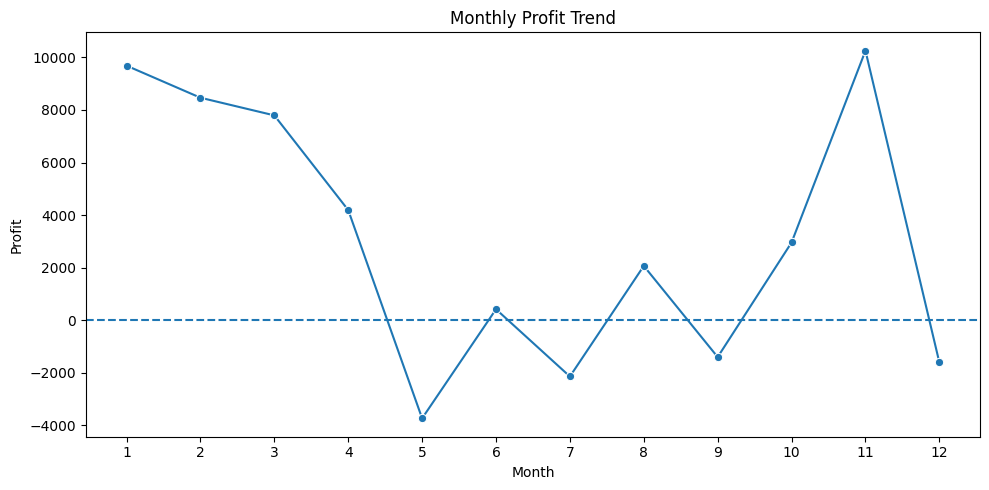

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_analysis.index,
    y=monthly_analysis["Profit"],
    marker="o"
)

plt.axhline(0, linestyle="--")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [21]:
customer_analysis = (
    sales.groupby("CustomerName")
    .agg(
        Sales=("Amount", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Order ID", "count")
    )
    .sort_values("Sales", ascending=False)
)

customer_analysis["Profit Margin %"] = (
    customer_analysis["Profit"] / customer_analysis["Sales"] * 100
)

print("Top 10 customers by sales:")
display(customer_analysis.head(10))

Top 10 customers by sales:


,Sales,Profit,Quantity,Transactions,Profit Margin %
CustomerName,,,,,
Harivansh,9902,-157,57,9,-1.585538
Madhav,9365,1848,53,13,19.733049
Madan Mohan,7766,2166,54,9,27.890806
Shiva,6339,669,46,9,10.553715
Vishakha,6120,-173,59,13,-2.826797
Vrinda,5820,917,54,12,15.756014
Lalita,5809,400,23,6,6.885867
Priyanka,5762,1276,79,21,22.145089
Shruti,5750,485,67,17,8.434783


In [22]:
loss_customers = (
    customer_analysis[customer_analysis["Profit"] < 0]
    .sort_values("Profit")
)

print("Top loss-making customers:")
display(loss_customers.head(10))

Top loss-making customers:


,Sales,Profit,Quantity,Transactions,Profit Margin %
CustomerName,,,,,
Shishu,3803,-1836,26,6,-48.277676
Tanvi,934,-916,7,1,-98.072805
Rutuja,1511,-900,28,6,-59.563203
Jay,3574,-843,29,6,-23.587017
Gopal,4836,-816,13,4,-16.873449
Chirag,3192,-731,34,10,-22.901003
Rishabh,2002,-685,21,6,-34.215784
Yash,789,-647,21,5,-82.002535
Nida,1201,-616,44,10,-51.290591


In [23]:
state_analysis = (
    sales.groupby("State")
    .agg(
        Sales=("Amount", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Order ID", "count")
    )
    .sort_values("Sales", ascending=False)
)

state_analysis["Profit Margin %"] = (
    state_analysis["Profit"] / state_analysis["Sales"] * 100
)

state_analysis

,Sales,Profit,Quantity,Transactions,Profit Margin %
State,,,,,
Maharashtra,102498,6963,1091,299,6.793303
Madhya Pradesh,87463,7382,1227,314,8.440140
Uttar Pradesh,38362,3358,387,87,8.753454
Delhi,22957,1958,290,76,8.528989
Rajasthan,22334,-323,282,74,-1.446225
Gujarat,21371,3001,328,87,14.042394
Punjab,16786,1571,216,60,9.358990
West Bengal,14328,2074,216,63,14.475154
Kerala,13871,2435,157,45,17.554610


In [24]:
payment_analysis = (
    sales.groupby("PaymentMode")
    .agg(
        Sales=("Amount", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Order ID", "count")
    )
    .sort_values("Sales", ascending=False)
)

payment_analysis["Profit Margin %"] = (
    payment_analysis["Profit"] / payment_analysis["Sales"] * 100
)

payment_analysis

,Sales,Profit,Quantity,Transactions,Profit Margin %
PaymentMode,,,,,
COD,155181,12547,2456,684,8.085397
Credit Card,86932,12612,672,163,14.507891
EMI,77881,4824,589,120,6.194065
UPI,68641,3286,1157,331,4.787226
Debit Card,49136,3694,741,202,7.517909


In [26]:
numeric_data = sales[["Amount", "Profit", "Quantity"]]

correlation = numeric_data.corr()

print("Correlation Matrix:")
display(correlation)

Correlation Matrix:


,Amount,Profit,Quantity
Amount,1.000000,0.309242,0.352486
Profit,0.309242,1.000000,0.063096
Quantity,0.352486,0.063096,1.000000


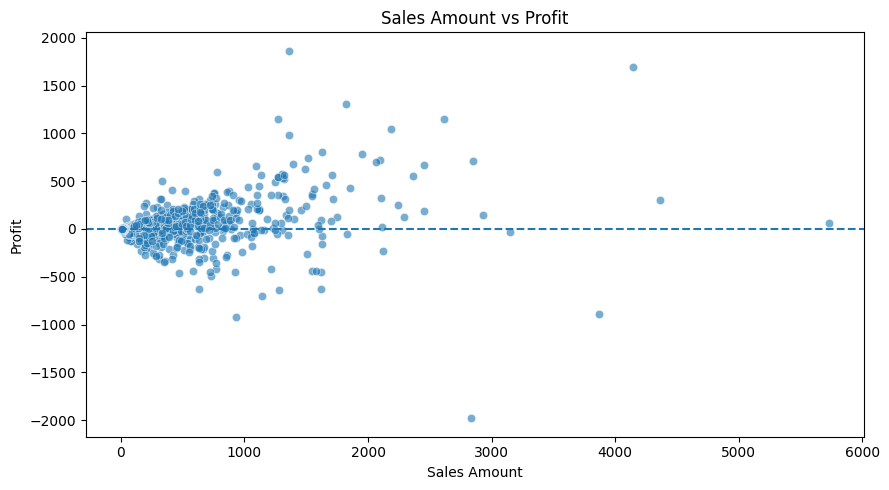

In [27]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=sales,
    x="Amount",
    y="Profit",
    alpha=0.6
)

plt.axhline(0, linestyle="--")
plt.title("Sales Amount vs Profit")
plt.xlabel("Sales Amount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()